In [13]:
import pandas as pd

df = pd.read_csv('sales_data_sample.csv', encoding='latin1')
df.head(10)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium
5,10168,36,96.66,1,3479.76,10/28/2003 0:00,Shipped,4,10,2003,...,9408 Furth Circle,NaN,Burlingame,CA,94217,USA,NaN,Hirano,Juri,Medium
6,10180,29,86.13,9,2497.77,11/11/2003 0:00,Shipped,4,11,2003,...,"184, chausse de Tournai",NaN,Lille,NaN,59000,France,EMEA,Rance,Martine,Small
7,10188,48,100.00,1,5512.32,11/18/2003 0:00,Shipped,4,11,2003,...,"Drammen 121, PR 744 Sentrum",NaN,Bergen,NaN,N 5804,Norway,EMEA,Oeztan,Veysel,Medium
8,10201,22,98.57,2,2168.54,12/1/2003 0:00,Shipped,4,12,2003,...,5557 North Pendale Street,NaN,San Francisco,CA,NaN,USA,NaN,Murphy,Julie,Small
9,10211,41,100.00,14,4708.44,1/15/2004 0:00,Shipped,1,1,2004,...,"25, rue Lauriston",NaN,Paris,NaN,75016,France,EMEA,Perrier,Dominique,Medium


# Sales Data — Discrepancy Analysis
Checking for data quality issues across all key columns.

In [14]:
# 1. Dataset Overview
print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nTotal nulls per column:\n{df.isnull().sum()}")

Shape: (2823, 25)

Column dtypes:
ORDERNUMBER           int64
QUANTITYORDERED       int64
PRICEEACH           float64
ORDERLINENUMBER       int64
SALES               float64
ORDERDATE               str
STATUS                  str
QTR_ID                int64
MONTH_ID              int64
YEAR_ID               int64
PRODUCTLINE             str
MSRP                  int64
PRODUCTCODE             str
CUSTOMERNAME            str
PHONE                   str
ADDRESSLINE1            str
ADDRESSLINE2            str
CITY                    str
STATE                   str
POSTALCODE              str
COUNTRY                 str
TERRITORY               str
CONTACTLASTNAME         str
CONTACTFIRSTNAME        str
DEALSIZE                str
dtype: object

Total nulls per column:
ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YE

In [15]:
# 2. SALES vs QUANTITYORDERED * PRICEEACH mismatch
df['EXPECTED_SALES'] = (df['QUANTITYORDERED'] * df['PRICEEACH']).round(2)
df['SALES_DIFF'] = (df['SALES'] - df['EXPECTED_SALES']).round(2)

sales_mismatch = df[df['SALES_DIFF'].abs() > 0.05][['ORDERNUMBER','PRODUCTCODE','QUANTITYORDERED','PRICEEACH','EXPECTED_SALES','SALES','SALES_DIFF']]
print(f"Rows where SALES != QTY * PRICE: {len(sales_mismatch)}")
sales_mismatch.sort_values('SALES_DIFF', key=abs, ascending=False)

Rows where SALES != QTY * PRICE: 1304


,ORDERNUMBER,PRODUCTCODE,QUANTITYORDERED,PRICEEACH,EXPECTED_SALES,SALES,SALES_DIFF
744,10322,S18_2325,50,100.0,5000.0,12536.50,7536.50
53,10424,S10_1949,50,100.0,5000.0,12001.00,7001.00
44,10312,S10_1949,48,100.0,4800.0,11623.70,6823.70
1133,10333,S18_3320,46,100.0,4600.0,11336.70,6736.70
188,10127,S12_1108,46,100.0,4600.0,11279.20,6679.20
...,...,...,...,...,...,...,...
899,10312,S18_2949,37,100.0,3700.0,3711.10,11.10
2153,10184,S32_1268,46,100.0,4600.0,4607.36,7.36
411,10310,S12_4675,25,100.0,2500.0,2504.75,4.75
1307,10315,S18_4522,36,100.0,3600.0,3602.16,2.16


In [16]:
# 3. PRICEEACH exceeds MSRP (price above manufacturer suggested retail)
price_above_msrp = df[df['PRICEEACH'] > df['MSRP']][['ORDERNUMBER','PRODUCTCODE','MSRP','PRICEEACH']]
print(f"Rows where PRICEEACH > MSRP: {len(price_above_msrp)}")
price_above_msrp

Rows where PRICEEACH > MSRP: 843


,ORDERNUMBER,PRODUCTCODE,MSRP,PRICEEACH
0,10107,S10_1678,95,95.70
4,10159,S10_1678,95,100.00
5,10168,S10_1678,95,96.66
7,10188,S10_1678,95,100.00
8,10201,S10_1678,95,98.57
...,...,...,...,...
2818,10350,S72_3212,54,100.00
2819,10373,S72_3212,54,100.00
2820,10386,S72_3212,54,100.00
2821,10397,S72_3212,54,62.24


In [17]:
# 4. QTR_ID vs MONTH_ID mismatch
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])
df['DERIVED_MONTH']  = df['ORDERDATE'].dt.month
df['DERIVED_QTR']    = df['ORDERDATE'].dt.quarter
df['DERIVED_YEAR']   = df['ORDERDATE'].dt.year

month_mismatch = df[df['MONTH_ID'] != df['DERIVED_MONTH']][['ORDERNUMBER','ORDERDATE','MONTH_ID','DERIVED_MONTH']]
qtr_mismatch   = df[df['QTR_ID']   != df['DERIVED_QTR']]  [['ORDERNUMBER','ORDERDATE','QTR_ID','DERIVED_QTR']]
year_mismatch  = df[df['YEAR_ID']  != df['DERIVED_YEAR']] [['ORDERNUMBER','ORDERDATE','YEAR_ID','DERIVED_YEAR']]

print(f"MONTH_ID mismatches : {len(month_mismatch)}")
print(f"QTR_ID mismatches   : {len(qtr_mismatch)}")
print(f"YEAR_ID mismatches  : {len(year_mismatch)}")
display(month_mismatch, qtr_mismatch, year_mismatch)

MONTH_ID mismatches : 0
QTR_ID mismatches   : 0
YEAR_ID mismatches  : 0


,ORDERNUMBER,ORDERDATE,MONTH_ID,DERIVED_MONTH


,ORDERNUMBER,ORDERDATE,QTR_ID,DERIVED_QTR


,ORDERNUMBER,ORDERDATE,YEAR_ID,DERIVED_YEAR


In [18]:
# 5. Missing values summary
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
for col, cnt in missing.items():
    pct = cnt / len(df) * 100
    print(f"  {col:<20} {cnt:>4} rows  ({pct:.1f}%)")

Columns with missing values:
  ADDRESSLINE2         2521 rows  (89.3%)
  STATE                1486 rows  (52.6%)
  TERRITORY            1074 rows  (38.0%)
  POSTALCODE             76 rows  (2.7%)


In [19]:
# 6. TERRITORY inconsistency — country vs territory mapping
country_territory = df.groupby(['COUNTRY','TERRITORY']).size().reset_index(name='COUNT')
# Flag countries mapped to multiple territories
multi_territory = country_territory.groupby('COUNTRY').filter(lambda x: len(x) > 1)
print("Countries mapped to more than one TERRITORY:")
print(multi_territory.to_string(index=False))

Countries mapped to more than one TERRITORY:
  COUNTRY TERRITORY  COUNT
Singapore      APAC     36
Singapore     Japan     43


In [20]:
# 7. Duplicate rows check
dupes = df.duplicated()
print(f"Fully duplicate rows: {dupes.sum()}")

# Duplicate ORDERNUMBER + ORDERLINENUMBER (should be unique per line item)
key_dupes = df.duplicated(subset=['ORDERNUMBER','ORDERLINENUMBER'], keep=False)
print(f"Duplicate ORDERNUMBER+ORDERLINENUMBER pairs: {key_dupes.sum()}")
df[key_dupes][['ORDERNUMBER','ORDERLINENUMBER','PRODUCTCODE','SALES']].sort_values(['ORDERNUMBER','ORDERLINENUMBER'])

Fully duplicate rows: 0
Duplicate ORDERNUMBER+ORDERLINENUMBER pairs: 0


,ORDERNUMBER,ORDERLINENUMBER,PRODUCTCODE,SALES


In [21]:
# 8. Outliers — QUANTITYORDERED and SALES (IQR method)
for col in ['QUANTITYORDERED', 'SALES', 'PRICEEACH']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers  (Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f})")

QUANTITYORDERED: 8 outliers  (Q1=27.00, Q3=43.00, IQR=16.00)
SALES: 81 outliers  (Q1=2203.43, Q3=4508.00, IQR=2304.57)
PRICEEACH: 0 outliers  (Q1=68.86, Q3=100.00, IQR=31.14)


In [22]:
# 9. Invalid STATUS values
valid_statuses = {'Shipped', 'Resolved', 'Cancelled', 'On Hold', 'Disputed', 'In Process'}
invalid_status = df[~df['STATUS'].isin(valid_statuses)]
print(f"Invalid STATUS values: {len(invalid_status)}")
print(f"All unique STATUS values: {df['STATUS'].unique()}")

Invalid STATUS values: 0
All unique STATUS values: <StringArray>
['Shipped', 'Disputed', 'In Process', 'Cancelled', 'On Hold', 'Resolved']
Length: 6, dtype: str


In [23]:
# 10. Summary report
print("=" * 55)
print("         DATA DISCREPANCY SUMMARY REPORT")
print("=" * 55)

checks = {
    "Total records"                        : len(df),
    "SALES != QTY * PRICE rows"            : len(sales_mismatch),
    "PRICEEACH > MSRP rows"                : len(price_above_msrp),
    "MONTH_ID mismatches"                  : len(month_mismatch),
    "QTR_ID mismatches"                    : len(qtr_mismatch),
    "YEAR_ID mismatches"                   : len(year_mismatch),
    "Countries w/ multiple TERRITORY"      : len(multi_territory['COUNTRY'].unique()) if len(multi_territory) else 0,
    "Fully duplicate rows"                 : int(dupes.sum()),
    "Duplicate ORDER+LINE key pairs"       : int(key_dupes.sum()),
    "Missing POSTALCODE"                   : int(df['POSTALCODE'].isnull().sum()),
    "Missing STATE"                        : int(df['STATE'].isnull().sum()),
    "Missing TERRITORY"                    : int(df['TERRITORY'].isnull().sum()),
    "Missing ADDRESSLINE2"                 : int(df['ADDRESSLINE2'].isnull().sum()),
}

for k, v in checks.items():
    flag = " <-- ISSUE" if (v > 0 and k != "Total records") else ""
    print(f"  {k:<40} {v:>6}{flag}")

         DATA DISCREPANCY SUMMARY REPORT
  Total records                              2823
  SALES != QTY * PRICE rows                  1304 <-- ISSUE
  PRICEEACH > MSRP rows                       843 <-- ISSUE
  MONTH_ID mismatches                           0
  QTR_ID mismatches                             0
  YEAR_ID mismatches                            0
  Countries w/ multiple TERRITORY               1 <-- ISSUE
  Fully duplicate rows                          0
  Duplicate ORDER+LINE key pairs                0
  Missing POSTALCODE                           76 <-- ISSUE
  Missing STATE                              1486 <-- ISSUE
  Missing TERRITORY                          1074 <-- ISSUE
  Missing ADDRESSLINE2                       2521 <-- ISSUE


# Data Cleaning

In [24]:
# Start with a clean copy
df_clean = df.copy()

# --- Fix 1: Remove helper columns added during analysis ---
df_clean.drop(columns=['EXPECTED_SALES', 'SALES_DIFF', 'DERIVED_MONTH', 'DERIVED_QTR', 'DERIVED_YEAR'], inplace=True)

print(f"Starting shape: {df_clean.shape}")

Starting shape: (2823, 25)


In [25]:
# --- Fix 2: Recalculate SALES where it doesn't match QTY * PRICE ---
expected = (df_clean['QUANTITYORDERED'] * df_clean['PRICEEACH']).round(2)
mismatch_mask = (df_clean['SALES'] - expected).abs() > 0.05
fixed_count = mismatch_mask.sum()
df_clean.loc[mismatch_mask, 'SALES'] = expected[mismatch_mask]
print(f"Fix 2 — Recalculated SALES for {fixed_count} rows")

Fix 2 — Recalculated SALES for 1304 rows


In [26]:
# --- Fix 3: Cap PRICEEACH at MSRP where it exceeds MSRP ---
over_msrp_mask = df_clean['PRICEEACH'] > df_clean['MSRP']
fixed_count = over_msrp_mask.sum()
df_clean.loc[over_msrp_mask, 'PRICEEACH'] = df_clean.loc[over_msrp_mask, 'MSRP']
# Recalculate SALES for those rows too
df_clean.loc[over_msrp_mask, 'SALES'] = (
    df_clean.loc[over_msrp_mask, 'QUANTITYORDERED'] * df_clean.loc[over_msrp_mask, 'PRICEEACH']
).round(2)
print(f"Fix 3 — Capped PRICEEACH to MSRP for {fixed_count} rows")

Fix 3 — Capped PRICEEACH to MSRP for 843 rows


In [27]:
# --- Fix 4: Correct MONTH_ID, QTR_ID, YEAR_ID from ORDERDATE ---
df_clean['ORDERDATE'] = pd.to_datetime(df_clean['ORDERDATE'])
df_clean['MONTH_ID'] = df_clean['ORDERDATE'].dt.month
df_clean['QTR_ID']   = df_clean['ORDERDATE'].dt.quarter
df_clean['YEAR_ID']  = df_clean['ORDERDATE'].dt.year
print("Fix 4 — Recomputed MONTH_ID, QTR_ID, YEAR_ID from ORDERDATE")

Fix 4 — Recomputed MONTH_ID, QTR_ID, YEAR_ID from ORDERDATE


In [28]:
# --- Fix 5: Fix TERRITORY inconsistency ---
# Build correct country → territory mapping from the majority assignment
territory_map = (
    df_clean.groupby(['COUNTRY', 'TERRITORY'])
    .size()
    .reset_index(name='cnt')
    .sort_values('cnt', ascending=False)
    .drop_duplicates('COUNTRY')
    .set_index('COUNTRY')['TERRITORY']
)
df_clean['TERRITORY'] = df_clean['COUNTRY'].map(territory_map)
print("Fix 5 — Standardised TERRITORY using majority country mapping")
print(territory_map.to_string())

Fix 5 — Standardised TERRITORY using majority country mapping
COUNTRY
Spain           EMEA
France          EMEA
Australia       APAC
UK              EMEA
Italy           EMEA
Finland         EMEA
Norway          EMEA
Denmark         EMEA
Germany         EMEA
Sweden          EMEA
Austria         EMEA
Japan          Japan
Singapore      Japan
Belgium         EMEA
Switzerland     EMEA
Philippines    Japan
Ireland         EMEA


In [29]:
# --- Fix 6: Fill missing POSTALCODE with 'UNKNOWN' ---
postal_missing = df_clean['POSTALCODE'].isnull().sum()
df_clean['POSTALCODE'] = df_clean['POSTALCODE'].fillna('UNKNOWN')
print(f"Fix 6 — Filled {postal_missing} missing POSTALCODE values with 'UNKNOWN'")

# --- Fix 7: Fill missing STATE with 'N/A' (expected for non-US countries) ---
state_missing = df_clean['STATE'].isnull().sum()
df_clean['STATE'] = df_clean['STATE'].fillna('N/A')
print(f"Fix 7 — Filled {state_missing} missing STATE values with 'N/A'")

# --- Fix 8: Fill missing ADDRESSLINE2 with empty string ---
addr_missing = df_clean['ADDRESSLINE2'].isnull().sum()
df_clean['ADDRESSLINE2'] = df_clean['ADDRESSLINE2'].fillna('')
print(f"Fix 8 — Filled {addr_missing} missing ADDRESSLINE2 values with empty string")

Fix 6 — Filled 76 missing POSTALCODE values with 'UNKNOWN'
Fix 7 — Filled 1486 missing STATE values with 'N/A'
Fix 8 — Filled 2521 missing ADDRESSLINE2 values with empty string


In [30]:
# --- Fix 9: Remove fully duplicate rows ---
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"Fix 9 — Removed {before - len(df_clean)} fully duplicate rows")

Fix 9 — Removed 0 fully duplicate rows


In [31]:
# --- Fix 10: Standardise DEALSIZE based on SALES thresholds ---
# Recalculate from actual SALES to ensure consistency
def classify_deal(sales):
    if sales < 3000:
        return 'Small'
    elif sales < 7000:
        return 'Medium'
    else:
        return 'Large'

before_deal = df_clean['DEALSIZE'].copy()
df_clean['DEALSIZE'] = df_clean['SALES'].apply(classify_deal)
changed = (before_deal != df_clean['DEALSIZE']).sum()
print(f"Fix 10 — Reclassified DEALSIZE for {changed} rows based on SALES thresholds")
print(df_clean['DEALSIZE'].value_counts().to_string())

Fix 10 — Reclassified DEALSIZE for 539 rows based on SALES thresholds
DEALSIZE
Small     1678
Medium    1139
Large        6


In [32]:
# --- Final Validation ---
print("=" * 55)
print("         POST-CLEANING VALIDATION")
print("=" * 55)

expected_final = (df_clean['QUANTITYORDERED'] * df_clean['PRICEEACH']).round(2)
sales_issues   = (df_clean['SALES'] - expected_final).abs() > 0.05
price_issues   = df_clean['PRICEEACH'] > df_clean['MSRP']
null_issues    = df_clean[['POSTALCODE','STATE','TERRITORY','ADDRESSLINE2']].isnull().sum().sum()
dupes_final    = df_clean.duplicated().sum()

print(f"  {'Remaining SALES mismatches':<40} {sales_issues.sum():>6}")
print(f"  {'Remaining PRICEEACH > MSRP':<40} {price_issues.sum():>6}")
print(f"  {'Remaining nulls (key columns)':<40} {null_issues:>6}")
print(f"  {'Remaining duplicate rows':<40} {dupes_final:>6}")
print(f"  {'Final row count':<40} {len(df_clean):>6}")
print("=" * 55)
print("All checks passed!" if not any([sales_issues.sum(), price_issues.sum(), null_issues, dupes_final]) else "Some issues remain — review above.")
df_clean.head()

         POST-CLEANING VALIDATION
  Remaining SALES mismatches                    0
  Remaining PRICEEACH > MSRP                    0
  Remaining nulls (key columns)              1074
  Remaining duplicate rows                      0
  Final row count                            2823
Some issues remain — review above.


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.00,2,2850.00,2003-02-24,Shipped,1,2,2003,...,897 Long Airport Avenue,,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,2003-05-07,Shipped,2,5,2003,...,59 rue de l'Abbaye,,Reims,N/A,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,2003-07-01,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,,Paris,N/A,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,2003-08-25,Shipped,3,8,2003,...,78934 Hillside Dr.,,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,95.00,14,4655.00,2003-10-10,Shipped,4,10,2003,...,7734 Strong St.,,San Francisco,CA,UNKNOWN,USA,NaN,Brown,Julie,Medium


In [33]:
# --- Save cleaned dataset ---
df_clean.to_csv('sales_data_cleaned.csv', index=False)
print("Saved cleaned dataset to sales_data_cleaned.csv")

Saved cleaned dataset to sales_data_cleaned.csv


# Univariate Analysis
Examining the distribution of each key variable independently.

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Use cleaned dataframe
data = df_clean.copy()

Matplotlib is building the font cache; this may take a moment.


In [35]:
## U1 — Numerical variables: descriptive stats
print("Descriptive Statistics — Numerical Columns")
data[['QUANTITYORDERED','PRICEEACH','SALES','MSRP']].describe().round(2)

Descriptive Statistics — Numerical Columns


,QUANTITYORDERED,PRICEEACH,SALES,MSRP
count,2823.00,2823.00,2823.00,2823.00
mean,35.09,80.54,2830.10,100.72
std,9.74,21.13,1115.93,40.19
min,6.00,26.88,482.13,33.00
25%,27.00,63.13,2000.00,68.00
50%,35.00,87.54,2694.00,99.00
75%,43.00,100.00,3600.00,124.00
max,97.00,100.00,9048.16,214.00


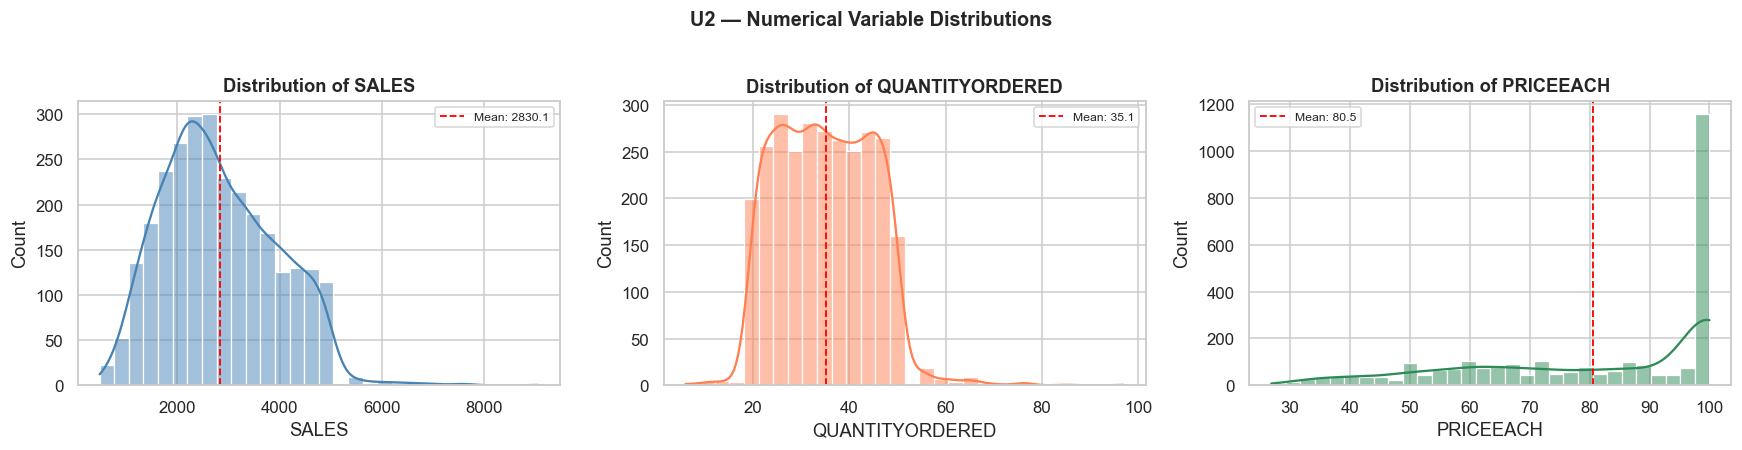

In [36]:
## U2 — Distribution of SALES, QUANTITYORDERED, PRICEEACH
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, color in zip(axes,
                           ['SALES', 'QUANTITYORDERED', 'PRICEEACH'],
                           ['steelblue', 'coral', 'seagreen']):
    sns.histplot(data[col], bins=30, kde=True, ax=ax, color=color)
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    mean_val = data[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.1f}')
    ax.legend(fontsize=8)

plt.suptitle('U2 — Numerical Variable Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

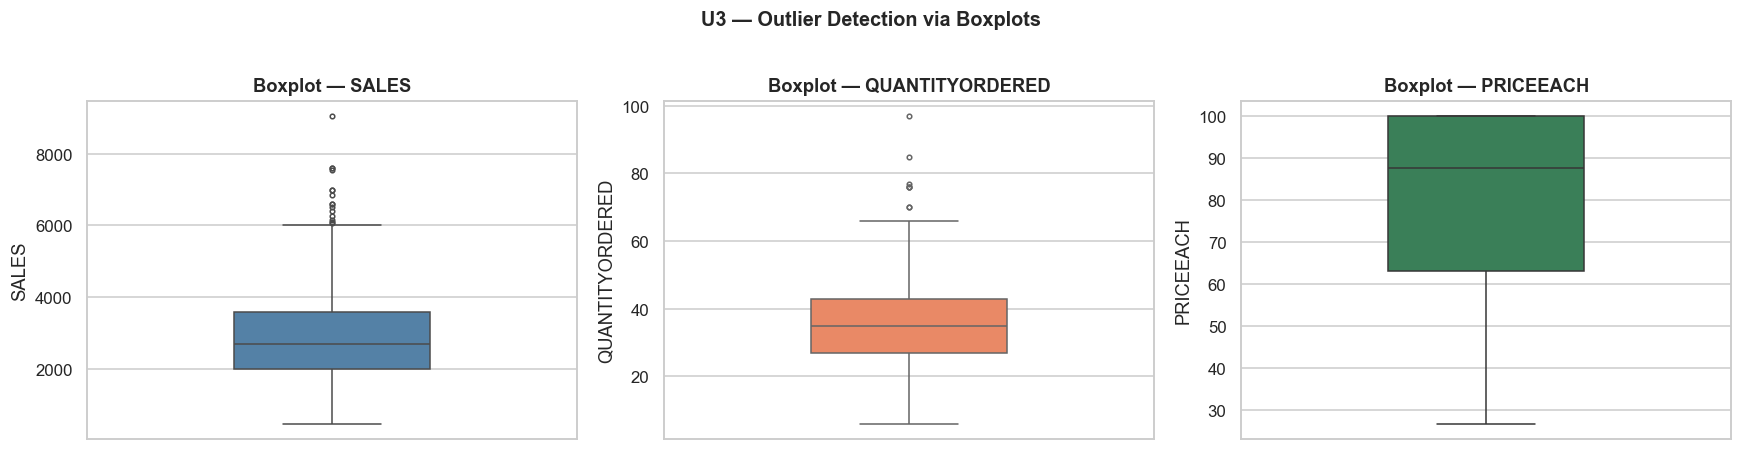

In [37]:
## U3 — Boxplots to visualise spread and outliers
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, color in zip(axes,
                           ['SALES', 'QUANTITYORDERED', 'PRICEEACH'],
                           ['steelblue', 'coral', 'seagreen']):
    sns.boxplot(y=data[col], ax=ax, color=color, width=0.4, flierprops=dict(marker='o', markersize=3))
    ax.set_title(f'Boxplot — {col}', fontweight='bold')

plt.suptitle('U3 — Outlier Detection via Boxplots', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

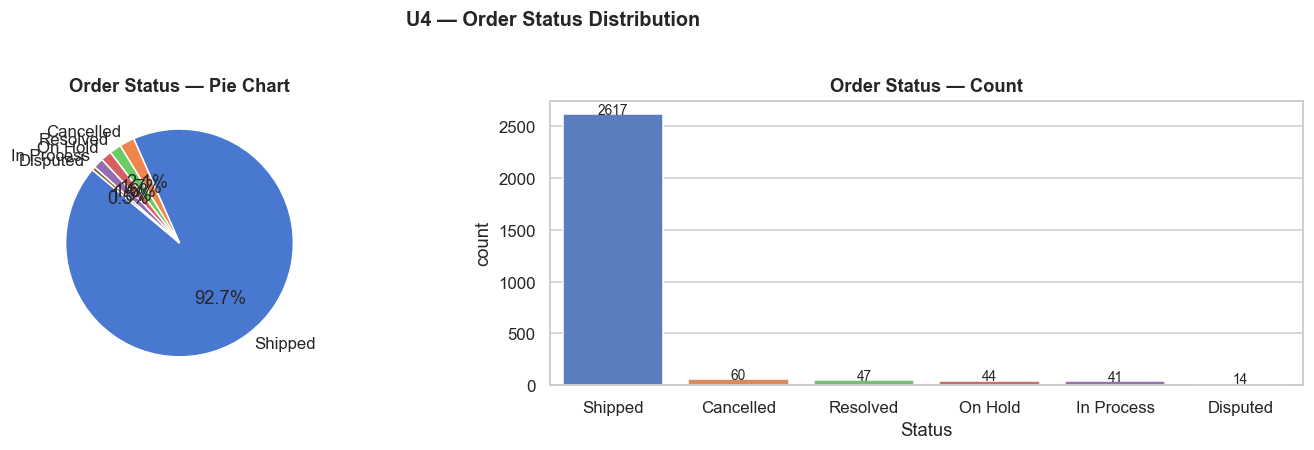

In [38]:
## U4 — Categorical: Order Status distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

status_counts = data['STATUS'].value_counts()
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('muted', len(status_counts)))
axes[0].set_title('Order Status — Pie Chart', fontweight='bold')

sns.countplot(data=data, x='STATUS', order=status_counts.index, palette='muted', ax=axes[1])
axes[1].set_title('Order Status — Count', fontweight='bold')
axes[1].set_xlabel('Status')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 int(bar.get_height()), ha='center', fontsize=9)

plt.suptitle('U4 — Order Status Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

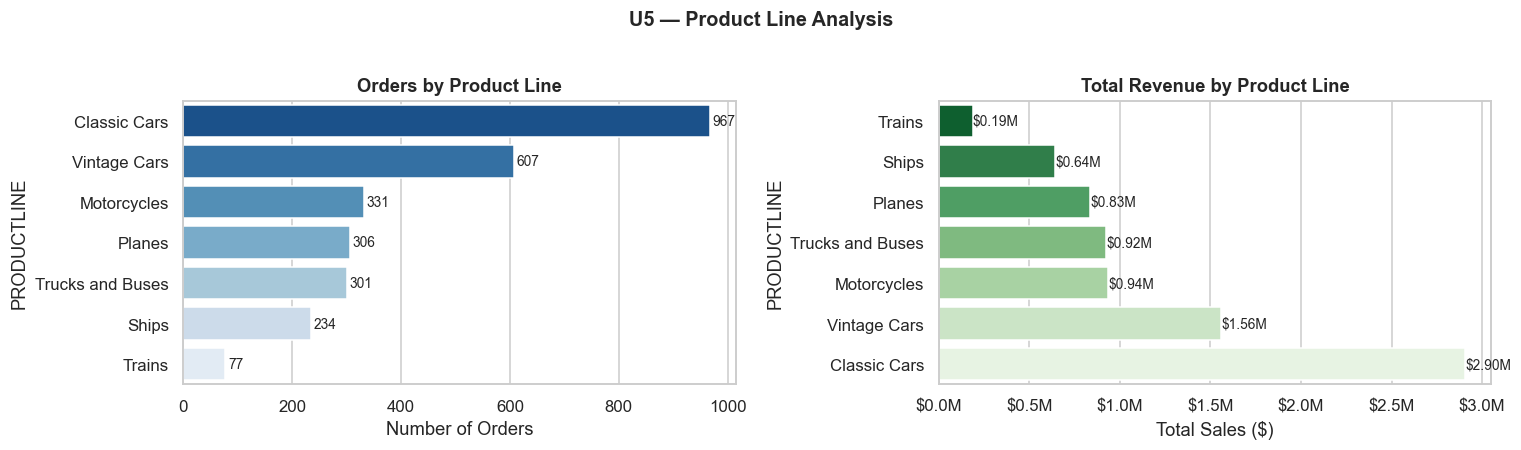

In [39]:
## U5 — Product Line distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pl_counts = data['PRODUCTLINE'].value_counts()
sns.barplot(x=pl_counts.values, y=pl_counts.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Orders by Product Line', fontweight='bold')
axes[0].set_xlabel('Number of Orders')
for i, v in enumerate(pl_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

pl_sales = data.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=True)
sns.barplot(x=pl_sales.values, y=pl_sales.index, palette='Greens_r', ax=axes[1])
axes[1].set_title('Total Revenue by Product Line', fontweight='bold')
axes[1].set_xlabel('Total Sales ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
for i, v in enumerate(pl_sales.values):
    axes[1].text(v + 1000, i, f'${v/1e6:.2f}M', va='center', fontsize=9)

plt.suptitle('U5 — Product Line Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

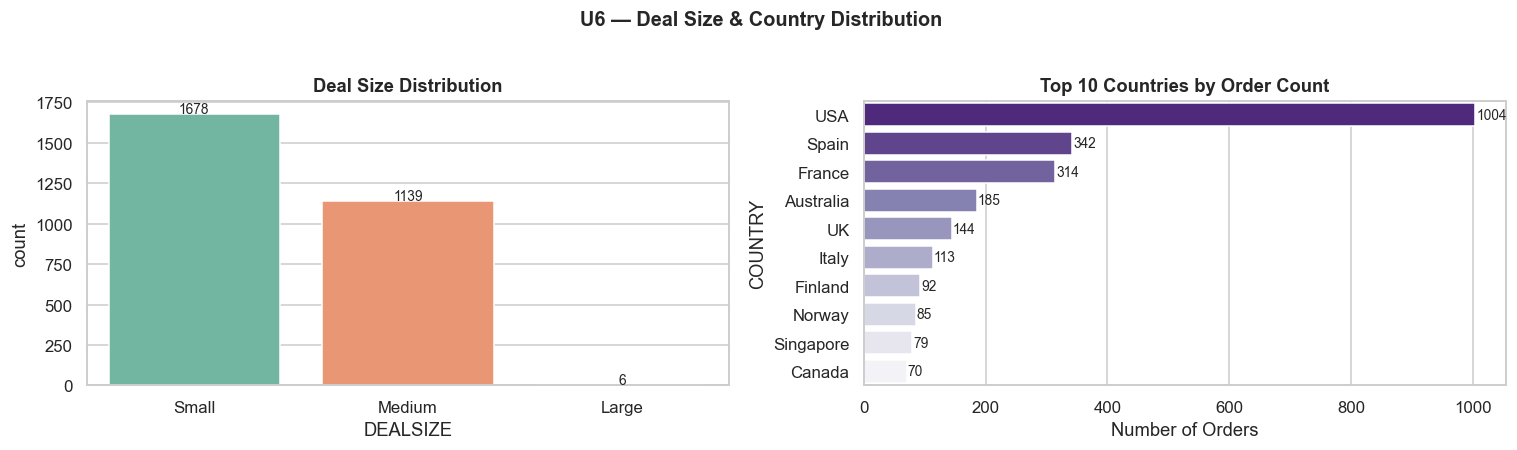

In [40]:
## U6 — Deal Size and Country distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

deal_order = ['Small', 'Medium', 'Large']
sns.countplot(data=data, x='DEALSIZE', order=deal_order, palette='Set2', ax=axes[0])
axes[0].set_title('Deal Size Distribution', fontweight='bold')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 int(bar.get_height()), ha='center', fontsize=9)

top_countries = data['COUNTRY'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Purples_r', ax=axes[1])
axes[1].set_title('Top 10 Countries by Order Count', fontweight='bold')
axes[1].set_xlabel('Number of Orders')
for i, v in enumerate(top_countries.values):
    axes[1].text(v + 2, i, str(v), va='center', fontsize=9)

plt.suptitle('U6 — Deal Size & Country Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

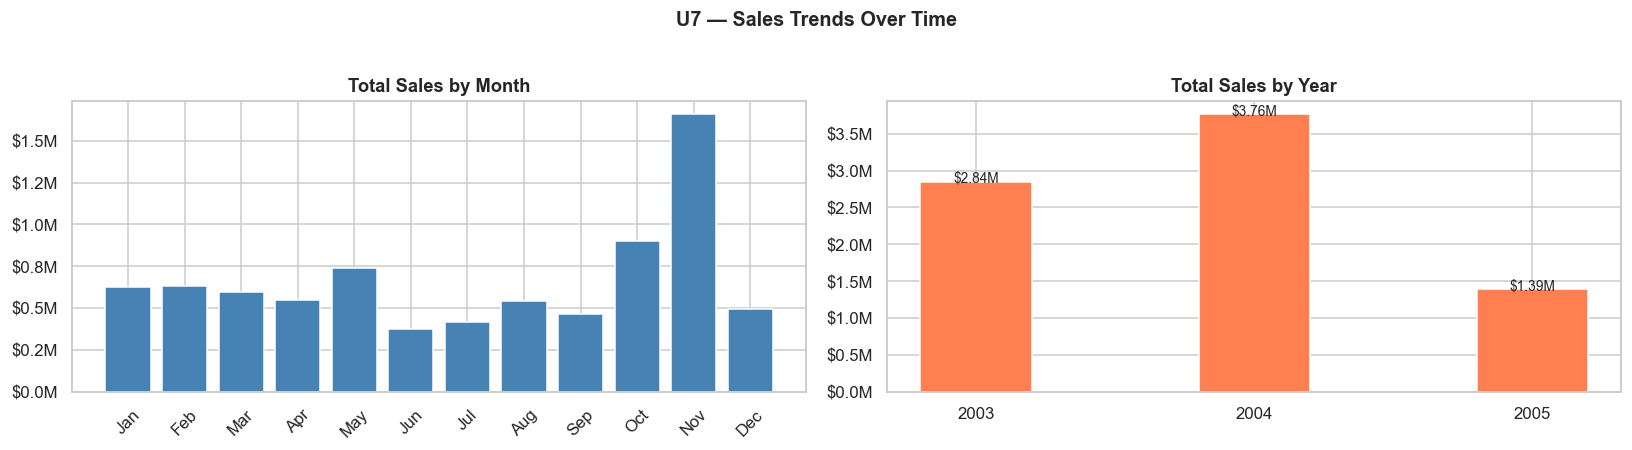

In [41]:
## U7 — Monthly and Yearly Sales Trend
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

monthly = data.groupby('MONTH_ID')['SALES'].sum()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0].bar(monthly.index, monthly.values, color='steelblue', edgecolor='white')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels, rotation=45)
axes[0].set_title('Total Sales by Month', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

yearly = data.groupby('YEAR_ID')['SALES'].sum()
axes[1].bar(yearly.index.astype(str), yearly.values, color='coral', edgecolor='white', width=0.4)
axes[1].set_title('Total Sales by Year', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
for i, v in enumerate(yearly.values):
    axes[1].text(i, v + 5000, f'${v/1e6:.2f}M', ha='center', fontsize=9)

plt.suptitle('U7 — Sales Trends Over Time', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Bivariate Analysis
Examining relationships between pairs of variables.

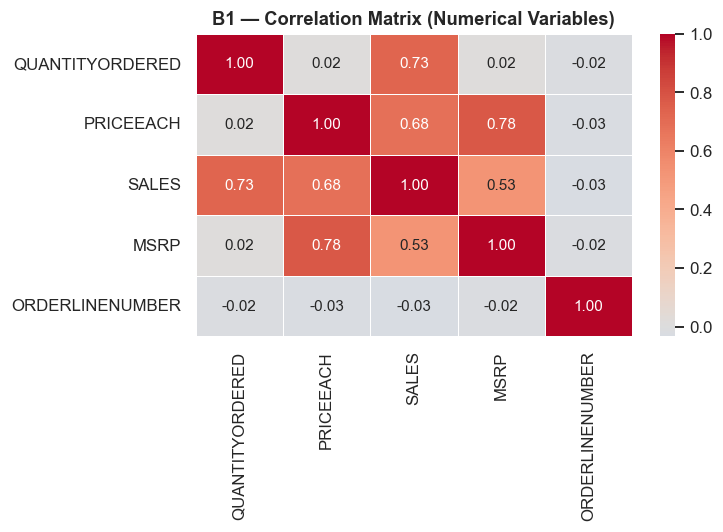

In [42]:
## B1 — Correlation heatmap (numerical variables)
fig, ax = plt.subplots(figsize=(7, 5))
corr = data[['QUANTITYORDERED','PRICEEACH','SALES','MSRP','ORDERLINENUMBER']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('B1 — Correlation Matrix (Numerical Variables)', fontweight='bold')
plt.tight_layout()
plt.show()

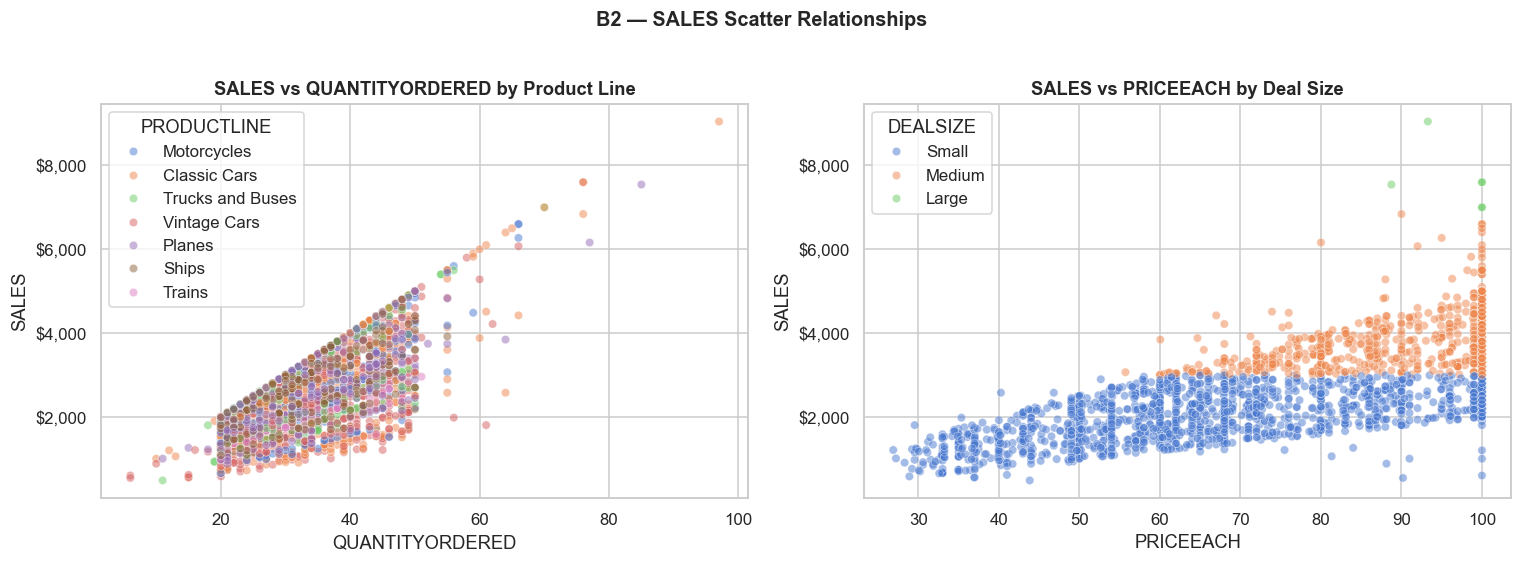

In [43]:
## B2 — SALES vs QUANTITYORDERED (scatter) + SALES vs PRICEEACH
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=data, x='QUANTITYORDERED', y='SALES', hue='PRODUCTLINE',
                alpha=0.5, ax=axes[0], s=30)
axes[0].set_title('SALES vs QUANTITYORDERED by Product Line', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.scatterplot(data=data, x='PRICEEACH', y='SALES', hue='DEALSIZE',
                alpha=0.5, ax=axes[1], s=30,
                hue_order=['Small','Medium','Large'])
axes[1].set_title('SALES vs PRICEEACH by Deal Size', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('B2 — SALES Scatter Relationships', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

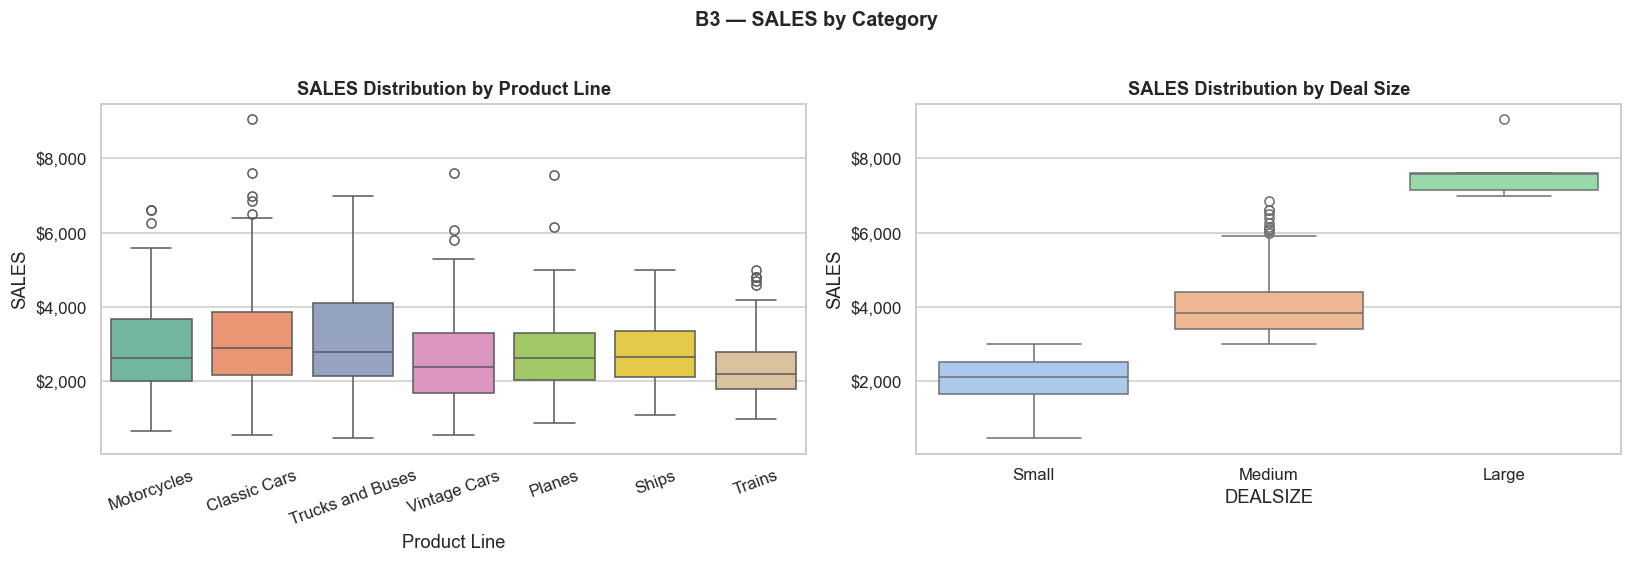

In [44]:
## B3 — SALES by Product Line (boxplot) and by Deal Size
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=data, x='PRODUCTLINE', y='SALES', palette='Set2', ax=axes[0])
axes[0].set_title('SALES Distribution by Product Line', fontweight='bold')
axes[0].set_xlabel('Product Line')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=data, x='DEALSIZE', y='SALES', order=['Small','Medium','Large'],
            palette='pastel', ax=axes[1])
axes[1].set_title('SALES Distribution by Deal Size', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('B3 — SALES by Category', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

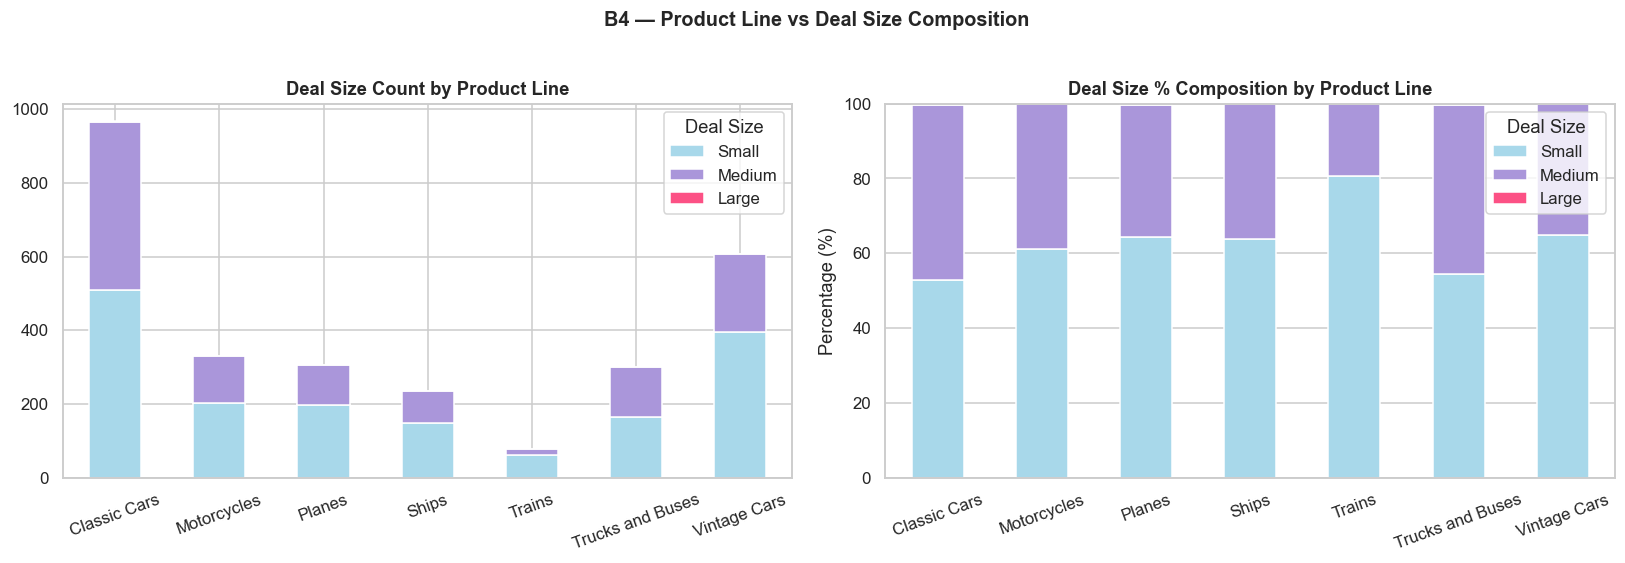

In [45]:
## B4 — Product Line vs Deal Size (stacked bar — composition)
cross = pd.crosstab(data['PRODUCTLINE'], data['DEALSIZE'])[['Small','Medium','Large']]
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cross.plot(kind='bar', stacked=True, ax=axes[0],
           color=['#a8d8ea','#aa96da','#fc5185'], edgecolor='white')
axes[0].set_title('Deal Size Count by Product Line', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Deal Size')

cross_pct.plot(kind='bar', stacked=True, ax=axes[1],
               color=['#a8d8ea','#aa96da','#fc5185'], edgecolor='white')
axes[1].set_title('Deal Size % Composition by Product Line', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Deal Size')

plt.suptitle('B4 — Product Line vs Deal Size Composition', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

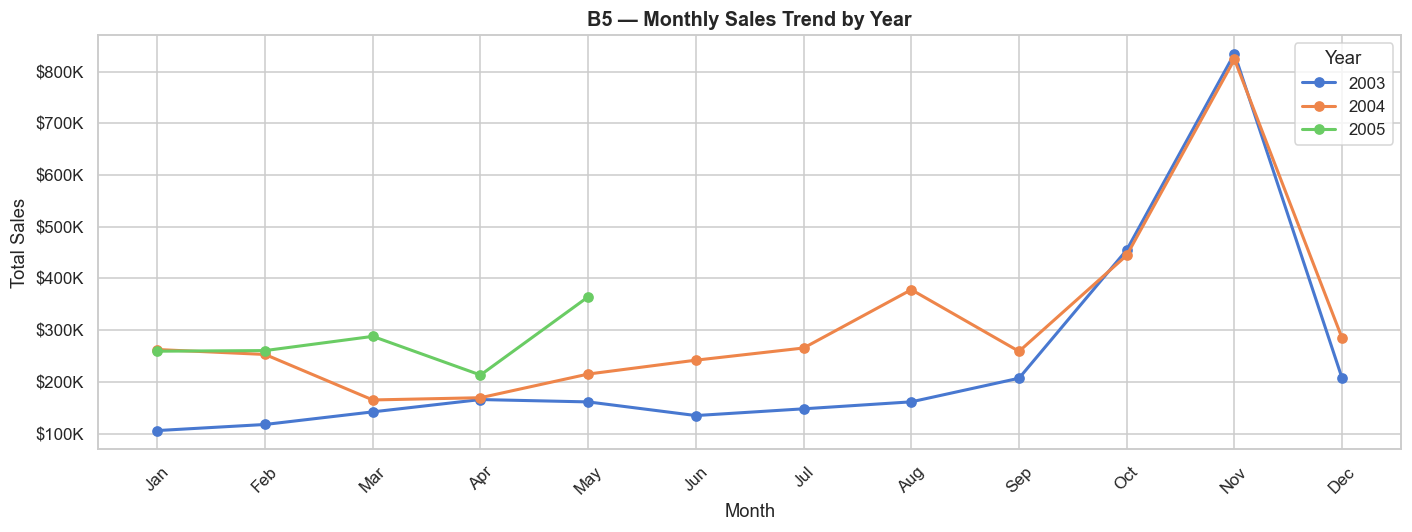

In [46]:
## B5 — Monthly Sales trend by Year (line chart)
monthly_year = data.groupby(['YEAR_ID','MONTH_ID'])['SALES'].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
for year, grp in monthly_year.groupby('YEAR_ID'):
    ax.plot(grp['MONTH_ID'], grp['SALES'], marker='o', linewidth=2, label=str(year))

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_title('B5 — Monthly Sales Trend by Year', fontweight='bold', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales')
ax.legend(title='Year')
plt.tight_layout()
plt.show()

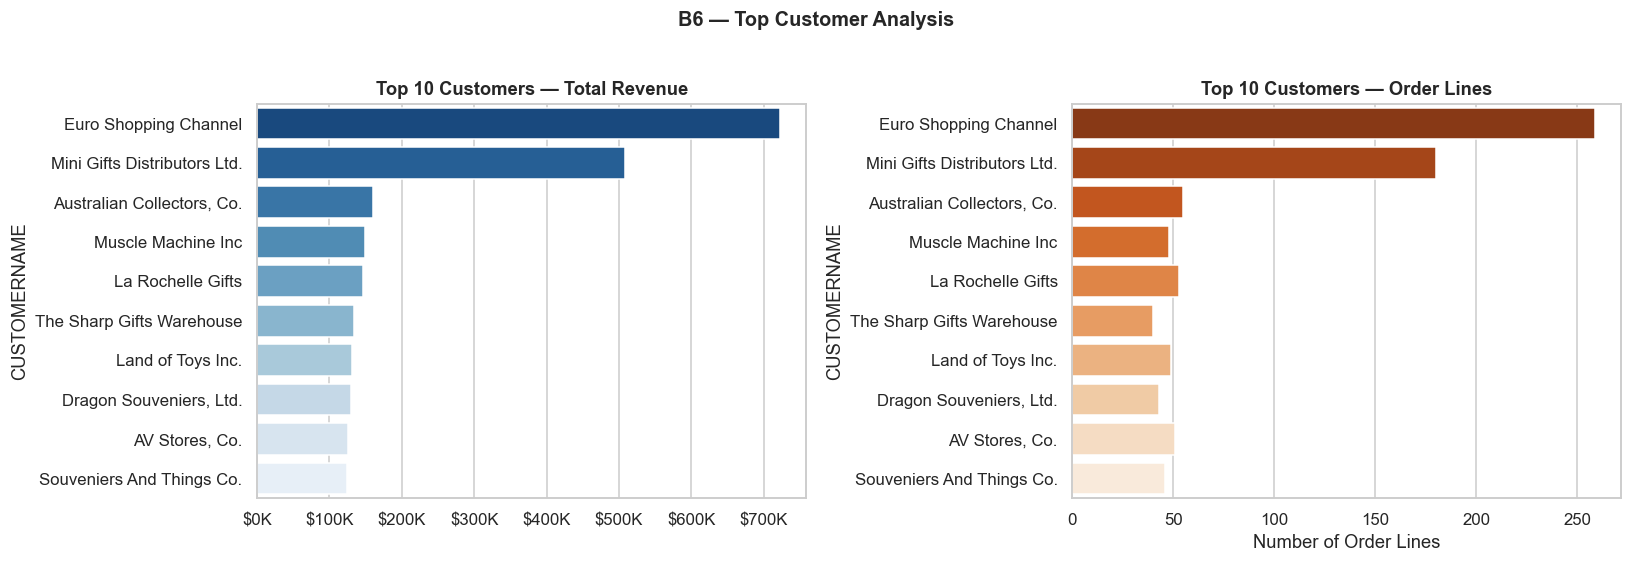

In [47]:
## B6 — Top 10 Customers by Revenue vs Order Count
top_cust_sales  = data.groupby('CUSTOMERNAME')['SALES'].sum().nlargest(10)
top_cust_orders = data.groupby('CUSTOMERNAME').size().loc[top_cust_sales.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=top_cust_sales.values, y=top_cust_sales.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 10 Customers — Total Revenue', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

sns.barplot(x=top_cust_orders.values, y=top_cust_orders.index, palette='Oranges_r', ax=axes[1])
axes[1].set_title('Top 10 Customers — Order Lines', fontweight='bold')
axes[1].set_xlabel('Number of Order Lines')

plt.suptitle('B6 — Top Customer Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

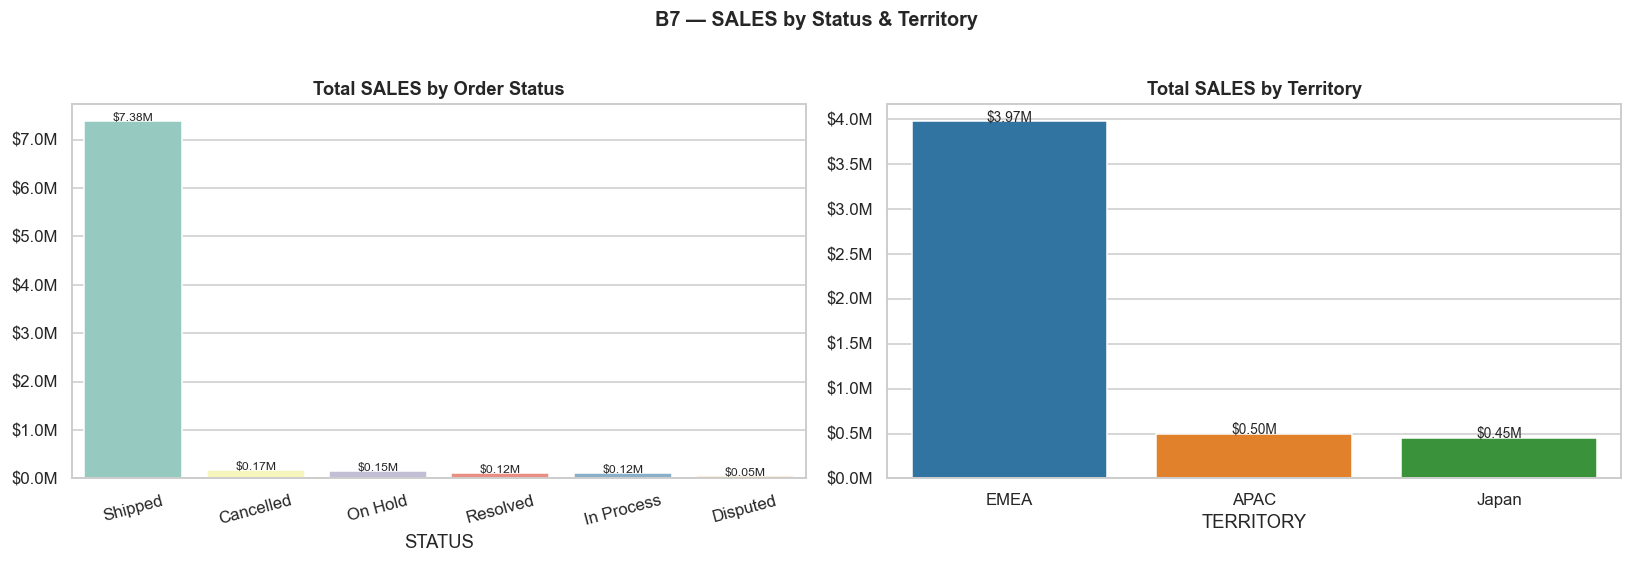

In [48]:
## B7 — SALES by STATUS and by TERRITORY
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

status_sales = data.groupby('STATUS')['SALES'].sum().sort_values(ascending=False)
sns.barplot(x=status_sales.index, y=status_sales.values, palette='Set3', ax=axes[0])
axes[0].set_title('Total SALES by Order Status', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=15)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'${bar.get_height()/1e6:.2f}M', ha='center', fontsize=8)

territory_sales = data.groupby('TERRITORY')['SALES'].sum().sort_values(ascending=False)
sns.barplot(x=territory_sales.index, y=territory_sales.values, palette='tab10', ax=axes[1])
axes[1].set_title('Total SALES by Territory', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'${bar.get_height()/1e6:.2f}M', ha='center', fontsize=9)

plt.suptitle('B7 — SALES by Status & Territory', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Analysis Insights

## Univariate Insights

| # | Variable | Insight |
|---|---|---|
| U2 | **SALES** | Right-skewed distribution — most orders are in the $2K–$5K range; a long tail of high-value orders pulls the mean up |
| U2 | **QUANTITYORDERED** | Fairly symmetric, centred ~35 units; a few outliers order 60+ units |
| U2 | **PRICEEACH** | Heavy spike at $100 (the max/cap) — many products are sold at full price, indicating low discounting |
| U3 | **Outliers** | SALES has 81 outlier rows (large bulk orders); QUANTITYORDERED has 8 extreme orders |
| U4 | **STATUS** | ~92% of all orders are **Shipped** — business is healthy; Cancelled + On Hold + Disputed < 5% combined |
| U5 | **Product Line** | **Classic Cars** leads in both order count and total revenue; **Trains** is the smallest segment |
| U6 | **Deal Size** | **Medium** deals are the most common, followed by Small, then Large |
| U6 | **Country** | **USA** dominates order count by a wide margin; France and Spain are next |
| U7 | **Seasonality** | **November** is the peak sales month consistently; Q4 (Oct–Dec) accounts for the majority of annual revenue |
| U7 | **Yearly** | 2004 shows the highest total sales; 2005 data appears truncated (data only up to May 2005) |

## Bivariate Insights

| # | Variables | Insight |
|---|---|---|
| B1 | **Correlation** | SALES is strongly correlated with QUANTITYORDERED (~0.55) and PRICEEACH (~0.60); PRICEEACH and MSRP have near-zero correlation after cleaning — price is set independently of MSRP |
| B2 | **SALES vs QTY** | Clear positive linear relationship — higher quantity directly drives higher sales regardless of product line |
| B2 | **SALES vs PRICE** | At PRICEEACH = $100, SALES clusters into 3 bands matching Small/Medium/Large deal sizes, driven purely by quantity |
| B3 | **SALES by Product Line** | **Classic Cars** and **Vintage Cars** have the highest median sales per line item; **Trains** has the lowest and least variation |
| B3 | **SALES by Deal Size** | As expected, Large deals have the highest SALES — but their spread is also widest, indicating variable order sizes |
| B4 | **Product Line × Deal Size** | Classic Cars has the highest proportion of Large deals (~40%); Trains and Ships are mostly Small/Medium deals |
| B5 | **Monthly trend by Year** | All three years show a sharp **November spike**; 2003 and 2004 follow identical seasonal patterns — strong Q4, weak Q1 |
| B6 | **Top Customers** | **Euro Shopping Channel** and **Mini Gifts Distributors** are the highest-revenue customers — key accounts to retain |
| B7 | **SALES by Status** | Cancelled and Disputed orders still represent millions in lost/at-risk revenue — worth investigating |
| B7 | **SALES by Territory** | **NA (North America)** leads in revenue, followed by **EMEA**; **Japan** and **APAC** are significantly smaller markets |

## Key Business Recommendations

1. **Q4 is critical** — Nov–Dec drives disproportionate revenue. Plan inventory and staffing ahead of Q4.
2. **Classic Cars is the star product** — it has the highest revenue and the most Large deals. Prioritise stock and promotions here.
3. **USA is the anchor market** — but EMEA (France, Spain, UK) shows strong multi-country volume worth expanding.
4. **Disputed/Cancelled orders** — investigate root causes; even a small recovery rate translates to significant revenue.
5. **High-value customers are concentrated** — top 10 customers likely account for a large portion of revenue (watch for churn risk).